In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("C:\\Users\\Shreyas\\Desktop\\shipment sure project\\Data\\raw\\shipment_dataset.xlsx")
data = df.copy()


# 1. MISSING VALUES
missing_values = np.random.choice(data.index, size=50, replace=False)
data.loc[missing_values, ["supplier_lead_time", "supplier_id", "total_order_value"]] = np.nan

# 2. INVALID CATEGORICAL VALUES

invalid_modes = ["Teleport", "Dragon", "UFO"]
cat_idx = np.random.choice(data.index, 30, replace=False)
data.loc[cat_idx, "shipment_mode"] = np.random.choice(invalid_modes, size=30)

data.to_csv("supply_chain_with_anom.csv", index=False)


"Anomalies added successfully!"

'Anomalies added successfully!'

In [2]:
import pandas as pd


df = pd.read_csv("supply_chain_with_anom.csv")

# 1. MISSING VALUES

missing_values = df[df[["supplier_lead_time", "supplier_id", "total_order_value"]].isna().any(axis=1)]

# 2. INVALID CATEGORICAL VALUES

valid_modes = ["Air", "Road", "Sea"] 
invalid_modes = df[~df["shipment_mode"].isin(valid_modes)]



#  RESULTS

print("\n===== ROWS WITH MISSING VALUES =====")
print(missing_values)

print("\n===== INVALID SHIPMENT MODES =====")
print(invalid_modes)


===== ROWS WITH MISSING VALUES =====
      order_id  supplier_id  supplier_rating  supplier_lead_time  order_date  \
175        176          NaN              4.8                 NaN  2024-07-11   
781        782          NaN              3.1                 NaN  2024-08-10   
792        793          NaN              4.8                 NaN  2024-08-23   
1110      1111          NaN              3.0                 NaN  2024-01-23   
1157      1158          NaN              2.7                 NaN  2024-09-29   
1844      1845          NaN              3.6                 NaN  2024-11-18   
1962      1963          NaN              3.3                 NaN  2024-06-27   
2956      2957          NaN              2.8                 NaN  2024-10-12   
3134      3135          NaN              4.3                 NaN  2024-02-28   
3543      3544          NaN              3.3                 NaN  2024-02-23   
3692      3693          NaN              4.1                 NaN  2024-10-03   
37


1. MISSING VALUES DETECTION

Column: supplier_id
Missing Count: 50
Missing at Indexes (first 20): [175, 781, 792, 1110, 1157, 1844, 1962, 2956, 3134, 3543, 3692, 3777, 3945, 4000, 4219, 4358, 4437, 4513, 4573, 4837]

Column: supplier_lead_time
Missing Count: 50
Missing at Indexes (first 20): [175, 781, 792, 1110, 1157, 1844, 1962, 2956, 3134, 3543, 3692, 3777, 3945, 4000, 4219, 4358, 4437, 4513, 4573, 4837]

Column: total_order_value
Missing Count: 50
Missing at Indexes (first 20): [175, 781, 792, 1110, 1157, 1844, 1962, 2956, 3134, 3543, 3692, 3777, 3945, 4000, 4219, 4358, 4437, 4513, 4573, 4837]

Column: delayed_reason_code
Missing Count: 1998
Missing at Indexes (first 20): [2, 7, 10, 13, 23, 40, 45, 49, 52, 60, 68, 71, 73, 74, 75, 79, 91, 93, 96, 101]

 2. INVALID CATEGORY VALUE DETECTION
Invalid shipment_mode detected at rows: [359, 467, 659, 792, 1093, 1563, 2011, 2159, 2190, 2370, 2388, 2936, 3005, 3095, 3685, 4082, 4818, 5276, 5493, 5891]
Total invalid entries: 30

BOXPLOT — Ou

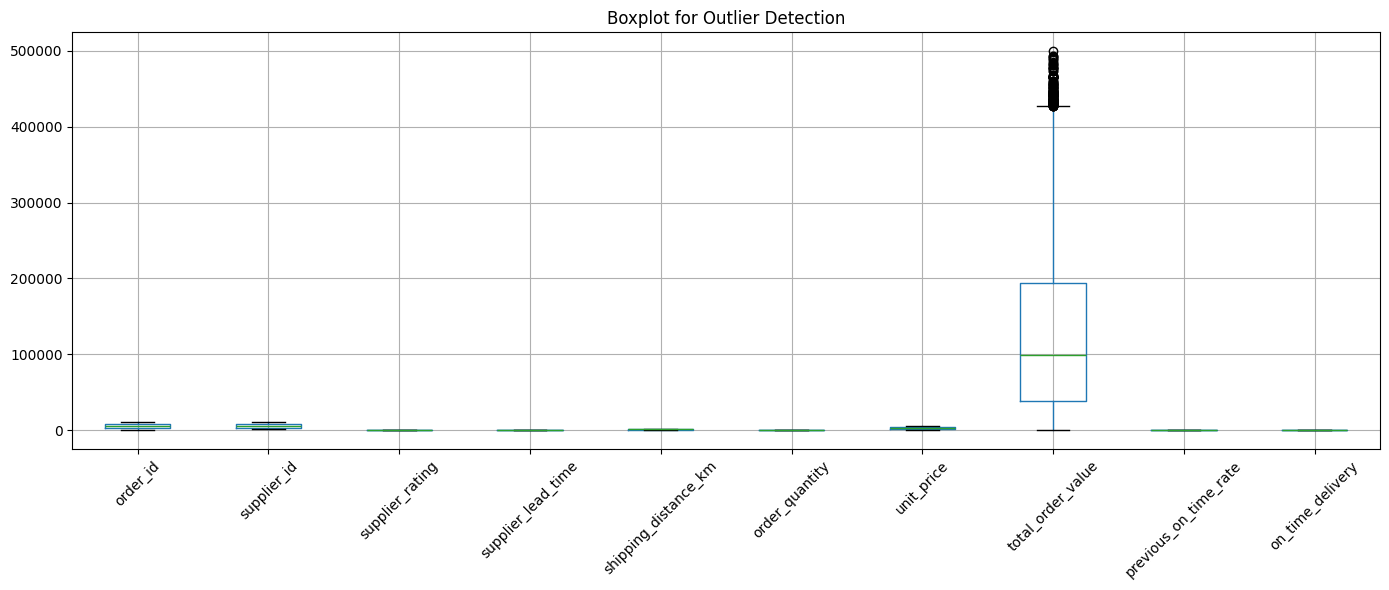

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset with anomalies
df = pd.read_csv("supply_chain_with_anom.csv")

print("\n===============================")
print("1. MISSING VALUES DETECTION")


missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print("No missing values found.")
else:
    for col, count in missing.items():
        idx = df[df[col].isnull()].index.tolist()
        print(f"\nColumn: {col}")
        print(f"Missing Count: {count}")
        print(f"Missing at Indexes (first 20): {idx[:20]}")
        
numeric_cols = df.select_dtypes(include=['number']).columns


print("\n=======================================")
print(" 2. INVALID CATEGORY VALUE DETECTION")

invalid_modes = ["Teleport", "Dragon", "UFO"]

invalid_idx = df[df["shipment_mode"].isin(invalid_modes)].index.tolist()

if invalid_idx:
    print(f"Invalid shipment_mode detected at rows: {invalid_idx[:20]}")
    print(f"Total invalid entries: {len(invalid_idx)}")
else:
    print("No invalid categorical entries found.")

print("\n===============================")
print("BOXPLOT — Outlier Visualization")

plt.figure(figsize=(14, 6))
df[numeric_cols].boxplot()
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [3]:

import pandas as pd

df=pd.read_csv("C:\\Users\\Shreyas\\Desktop\\shipment sure project\\Data\\processed\\supply_chain_with_anom.csv")
df_clean = df.copy()

# FIX MISSING VALUES

num_cols = [
    col for col in df_clean.select_dtypes(include=['int64', 'float64']).columns
    if col not in ['supplier_id', 'order_id']  # adjust if needed
]

cat_cols = df_clean.select_dtypes(include=['object']).columns

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fix categorical
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values fixed.")

# fix invalid categorical values
invalid_modes = ["Teleport", "Dragon", "UFO"]

# most frequent correct category
valid_mode = df_clean.loc[~df_clean['shipment_mode'].isin(invalid_modes), 
                          'shipment_mode'].mode()[0]

# replace invalid entries with valid most frequent value
df_clean.loc[df_clean['shipment_mode'].isin(invalid_modes), 'shipment_mode'] = valid_mode

print("Invalid categorical entries fixed.")

df_clean.to_csv("shipment_dataset_clean_fixed.csv", index=False)
print("\nDataset successfully cleaned and saved as: shipment_dataset_clean_fixed.csv")

Missing values fixed.
Invalid categorical entries fixed.

Dataset successfully cleaned and saved as: shipment_dataset_clean_fixed.csv


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load CLEANED dataset
df = pd.read_csv(
    "C:\\Users\\Shreyas\\Desktop\\shipment sure project\\Data\\processed\\shipment_dataset_with_weekend_features.csv"
)

# =========================
# FEATURE ENGINEERING
# =========================

# Log transform
df['log_order_value'] = np.log1p(df['total_order_value'])

# Target
y = df["on_time_delivery"]

# Drop leakage + IDs
X = df.drop(columns=["on_time_delivery", "total_order_value", "supplier_id", "order_id"], errors='ignore')

# Encode categoricals
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    
# ================================
# HANDLE ANY REMAINING NaN (CRITICAL)
# ================================
X = X.fillna(X.median())

# =========================
# TRAIN-TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")


Training set shape: (8000, 18)
Test set shape: (2000, 18)


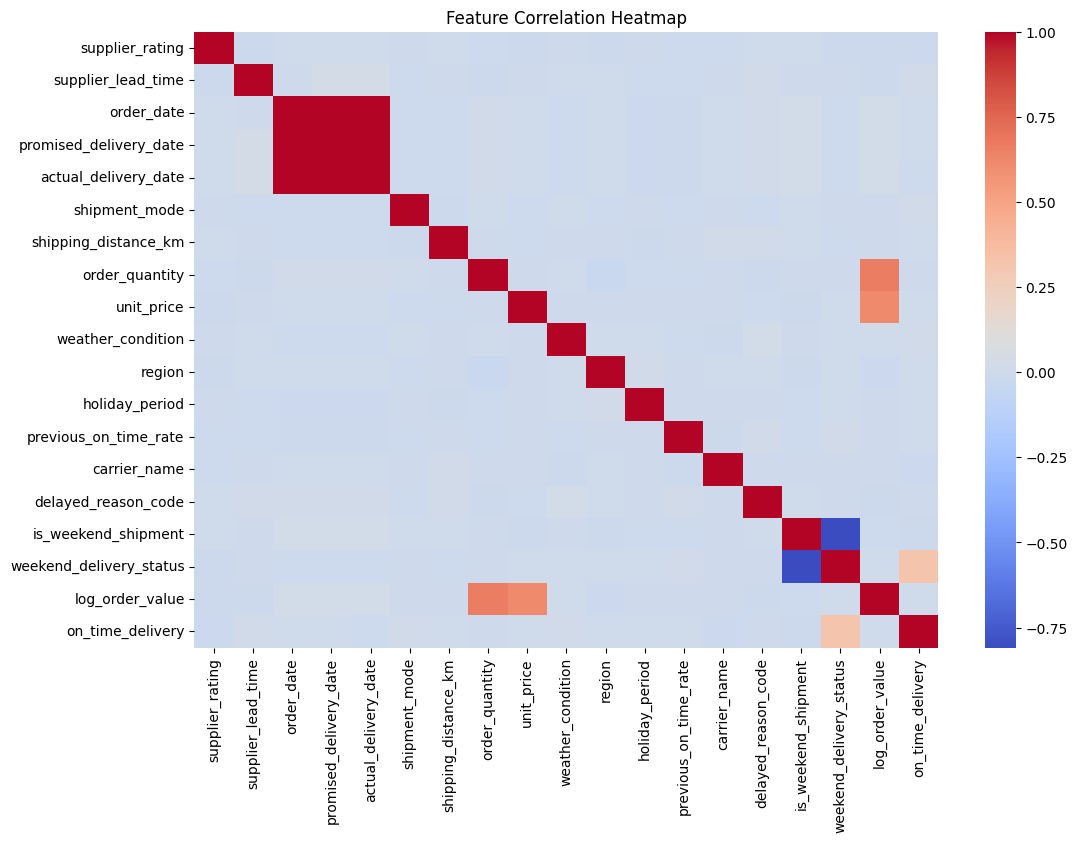

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns


corr_cols = X.copy()
corr_cols['on_time_delivery'] = y

plt.figure(figsize=(12,8))
sns.heatmap(corr_cols.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()
